In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random

In [ ]:
G_real = nx.read_edgelist("Wiki-Vote.txt", comments="#", create_using=nx.DiGraph(), nodetype=int)
N = G_real.number_of_nodes()
L = G_real.number_of_edges()

print("Wiki-Vote Real network")
print(f"nodes: {N}   edges: {L}")



print("Erdos-Renyi network")
p = L / (N * (N - 1))
G_er = nx.erdos_renyi_graph(n=N, p=p, directed=True)

print(f"Erdos-Renyi nodes: {G_er.number_of_nodes()}   edges: {G_er.number_of_edges()}")



print("Barabasi-Albert network")
m = int(round(L / N)) 
G_ba = nx.barabasi_albert_graph(n=N, m=m)

print(f"Barabasi-Albert nodes: {G_ba.number_of_nodes()}   edges: {G_ba.number_of_edges()}")

Wiki-Vote Real network
nodes: 7115   edges: 103689
Erdos-Renyi network
Erdos-Renyi nodes: 7115   edges: 103681
Barabasi-Albert network
Barabasi-Albert nodes: 7115   edges: 106500


In [15]:

def approx_average_shortest_path(G, num_samples=100):
    nodes = list(G.nodes())
    sample_nodes = random.sample(nodes, min(num_samples, len(nodes)))
    
    total_path_length = 0
    total_paths_counted = 0
    
    for source in sample_nodes:
        paths = nx.shortest_path_length(G, source=source)
        for target, length in paths.items():
            if source != target: 
                total_path_length += length
                total_paths_counted += 1
                
    if total_paths_counted == 0:
        return 0 
        
    return total_path_length / total_paths_counted


def analyze_network(G, name, approximate=True):
    print(name)
    
    if (G.is_directed()):
        in_degrees = dict(G.in_degree())
        out_degrees = dict(G.out_degree())
        
        print(f"In-Degrees  Min: {min(in_degrees.values())}")
        print(f"Out-Degrees  Min: {min(out_degrees.values())}")
        print(f"In-Degrees  Max: {max(in_degrees.values())}")
        print(f"Out-Degrees  Max: {max(out_degrees.values())}")
        print(f"In-Degrees  Avg: {sum(in_degrees.values()) / G.number_of_nodes()}")
        print(f"Out-Degrees  Avg: {sum(out_degrees.values()) / G.number_of_nodes()}")
        
        weak_connected_components = list(nx.weakly_connected_components(G))        
        weak_largest_cc_nodes = max(weak_connected_components, key=len)
        weak_largest_cc = G.subgraph(weak_largest_cc_nodes)
        
        strong_connected_components = list(nx.strongly_connected_components(G))
        strong_largest_cc_nodes = max(strong_connected_components, key=len)
        strong_largest_cc = G.subgraph(strong_largest_cc_nodes)
        
        print(f"Nr. of Weakly Connected Components: {len(weak_connected_components)}")
        print(f"Nr. of Strongly Connected Components: {len(strong_connected_components)}")

        print(f"Size of largest weak component: {len(weak_largest_cc_nodes)}")
        print(f"Size of largest strong component: {len(strong_largest_cc_nodes)}")

        if(approximate):
            print(f"Approximate Avg Shortest Path (weak): {approx_average_shortest_path(weak_largest_cc, num_samples=100):.4f}")
            print(f"Approximate Avg Shortest Path (strong): {approx_average_shortest_path(strong_largest_cc, num_samples=100):.4f}")

            print(f"Approximate Diameter of Largest Strongly Connected Component: {nx.approximation.diameter(strong_largest_cc)}")
        else:
            # print(f"Avg Shortest Path (weak): {nx.average_shortest_path_length(weak_largest_cc):.4f}")
            print(f"Avg Shortest Path (strong): {nx.average_shortest_path_length(strong_largest_cc):.4f}")
            
            print(f"Diameter of Largest Strongly Connected Component: {nx.diameter(strong_largest_cc)}")

        print(F"Avg Clustering Coefficient (directed): {nx.average_clustering(G):.4f}")
        print(f"Avg Clustering Coefficient (undirected): {nx.average_clustering(G.to_undirected() ):.4f}")
    
        in_sorted_nodes = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)
        out_sorted_nodes = sorted(out_degrees.items(), key=lambda x: x[1], reverse=True)
        print(f"Top 3 Most Important Nodes by in-degree: {in_sorted_nodes[:3]}")
        print(f"Top 3 Most Important Nodes by out-degree: {out_sorted_nodes[:3]}")
        
        pagerank = nx.pagerank(G)
        print(f"Top 3 Most Important Nodes by PageRank: {sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:3]}")
        
        betweenness = nx.betweenness_centrality(G, k=200)
        print(f"Top 3 Most Important Nodes by Betweenness: {sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:3]}")

    else:
        degrees = dict(G.degree())
        print(f"Degrees  Min: {min(degrees.values())}")
        print(f"Degrees  Max: {max(degrees.values())}")
        print(f"Degrees  Avg: {sum(degrees.values()) / G.number_of_nodes()}")
            
        connected_components = list(nx.connected_components(G))
        largest_cc_nodes = max(connected_components, key=len)
        largest_cc = G.subgraph(largest_cc_nodes)
        
        print(f"Nr. of connected components: {len(connected_components)}")
        
        print(f"Size of largest component: {len(largest_cc_nodes)}")
        
        if(approximate):
            print(f"Approximate Avg Shortest Path: {approx_average_shortest_path(largest_cc, num_samples=100):.4f}")
            print(f"Approximate Diameter: {nx.approximation.diameter(largest_cc)}")
        else:
            print(f"Avg Shortest Path: {nx.average_shortest_path_length(largest_cc):.4f}")
            print(f"Diameter: {nx.diameter(largest_cc)}")        
        
        print(f"Avg Clustering Coefficient: {nx.average_clustering(G):.4f}")
        
        degrees = dict(G.degree())
        sorted_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)
        print(f"Top 3 Most Important Nodes by degree: {sorted_nodes[:3]}")

        pagerank = nx.pagerank(G)
        print(f"Top 3 Most Important Nodes by PageRank: {sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:3]}")
        
        betweenness = nx.betweenness_centrality(G, k=200)
        print(f"Top 3 Most Important Nodes by Betweenness: {sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:3]}")

In [16]:
analyze_network(G_real, "Wiki-Vote Real", approximate=False)

Wiki-Vote Real
In-Degrees  Min: 0
Out-Degrees  Min: 0
In-Degrees  Max: 457
Out-Degrees  Max: 893
In-Degrees  Avg: 14.573295853829936
Out-Degrees  Avg: 14.573295853829936
Nr. of Weakly Connected Components: 24
Nr. of Strongly Connected Components: 5816
Size of largest weak component: 7066
Size of largest strong component: 1300
Avg Shortest Path (strong): 2.8793
Diameter of Largest Strongly Connected Component: 9
Avg Clustering Coefficient (directed): 0.0816
Avg Clustering Coefficient (undirected): 0.1409
Top 3 Most Important Nodes by in-degree: [(4037, 457), (15, 361), (2398, 340)]
Top 3 Most Important Nodes by out-degree: [(2565, 893), (766, 773), (11, 743)]
Top 3 Most Important Nodes by PageRank: [(4037, 0.004612715891167545), (15, 0.0036812207295292714), (6634, 0.003524813657640258)]
Top 3 Most Important Nodes by Betweenness: [(1549, 0.015908288064621523), (2565, 0.015679147102509044), (15, 0.01448570274069138)]


In [98]:
analyze_network(G_real, "Wiki-Vote Real")

Wiki-Vote Real
In-Degrees  Min: 0
Out-Degrees  Min: 0
In-Degrees  Max: 457
Out-Degrees  Max: 893
In-Degrees  Avg: 14.573295853829936
Out-Degrees  Avg: 14.573295853829936
Nr. of Weakly Connected Components: 24
Nr. of Strongly Connected Components: 5816
Size of largest weak component: 7066
Size of largest strong component: 1300
Approximate Avg Shortest Path (weak): 3.3642
Approximate Avg Shortest Path (strong): 2.8462
Approximate Diameter of Largest Strongly Connected Component: 9
Avg Clustering Coefficient (directed): 0.0816
Avg Clustering Coefficient (undirected): 0.1409
Top 3 Most Important Nodes by in-degree: [(4037, 457), (15, 361), (2398, 340)]
Top 3 Most Important Nodes by out-degree: [(2565, 893), (766, 773), (11, 743)]
Top 3 Most Important Nodes by PageRank: [(4037, 0.004612715891167545), (15, 0.0036812207295292714), (6634, 0.003524813657640258)]
Top 3 Most Important Nodes by Betweenness: [(2565, 0.017786548129045135), (1549, 0.015683545019020206), (15, 0.013551869818670978)]


In [99]:
analyze_network(G_er, "Erdos-Renyi Random")

Erdos-Renyi Random
In-Degrees  Min: 2
Out-Degrees  Min: 3
In-Degrees  Max: 30
Out-Degrees  Max: 34
In-Degrees  Avg: 14.60449754040759
Out-Degrees  Avg: 14.60449754040759
Nr. of Weakly Connected Components: 1
Nr. of Strongly Connected Components: 1
Size of largest weak component: 7115
Size of largest strong component: 7115
Approximate Avg Shortest Path (weak): 3.6076
Approximate Avg Shortest Path (strong): 3.6063
Approximate Diameter of Largest Strongly Connected Component: 5
Avg Clustering Coefficient (directed): 0.0020
Avg Clustering Coefficient (undirected): 0.0041
Top 3 Most Important Nodes by in-degree: [(2671, 30), (2868, 29), (5125, 29)]
Top 3 Most Important Nodes by out-degree: [(47, 34), (1974, 32), (543, 30)]
Top 3 Most Important Nodes by PageRank: [(2868, 0.0002950639087517976), (2671, 0.00028373356928171404), (1381, 0.0002663990038077522)]
Top 3 Most Important Nodes by Betweenness: [(5125, 0.0020783276626197204), (1531, 0.002063152955218117), (656, 0.00204122676620571)]


In [100]:
analyze_network(G_ba, "Barabasi-Albert Scale-Free")

Barabasi-Albert Scale-Free
Degrees  Min: 15
Degrees  Max: 688
Degrees  Avg: 29.93675333801827
Nr. of connected components: 1
Size of largest component: 7115
Approximate Avg Shortest Path: 2.7909
Approximate Diameter: 4
Avg Clustering Coefficient: 0.0186
Top 3 Most Important Nodes by degree: [(0, 688), (16, 462), (21, 426)]
Top 3 Most Important Nodes by PageRank: [(0, 0.002761591235096521), (16, 0.001862479753841373), (21, 0.0017187561674513758)]
Top 3 Most Important Nodes by Betweenness: [(0, 0.03863341131640769), (18, 0.02649317496060638), (16, 0.025828357594638553)]


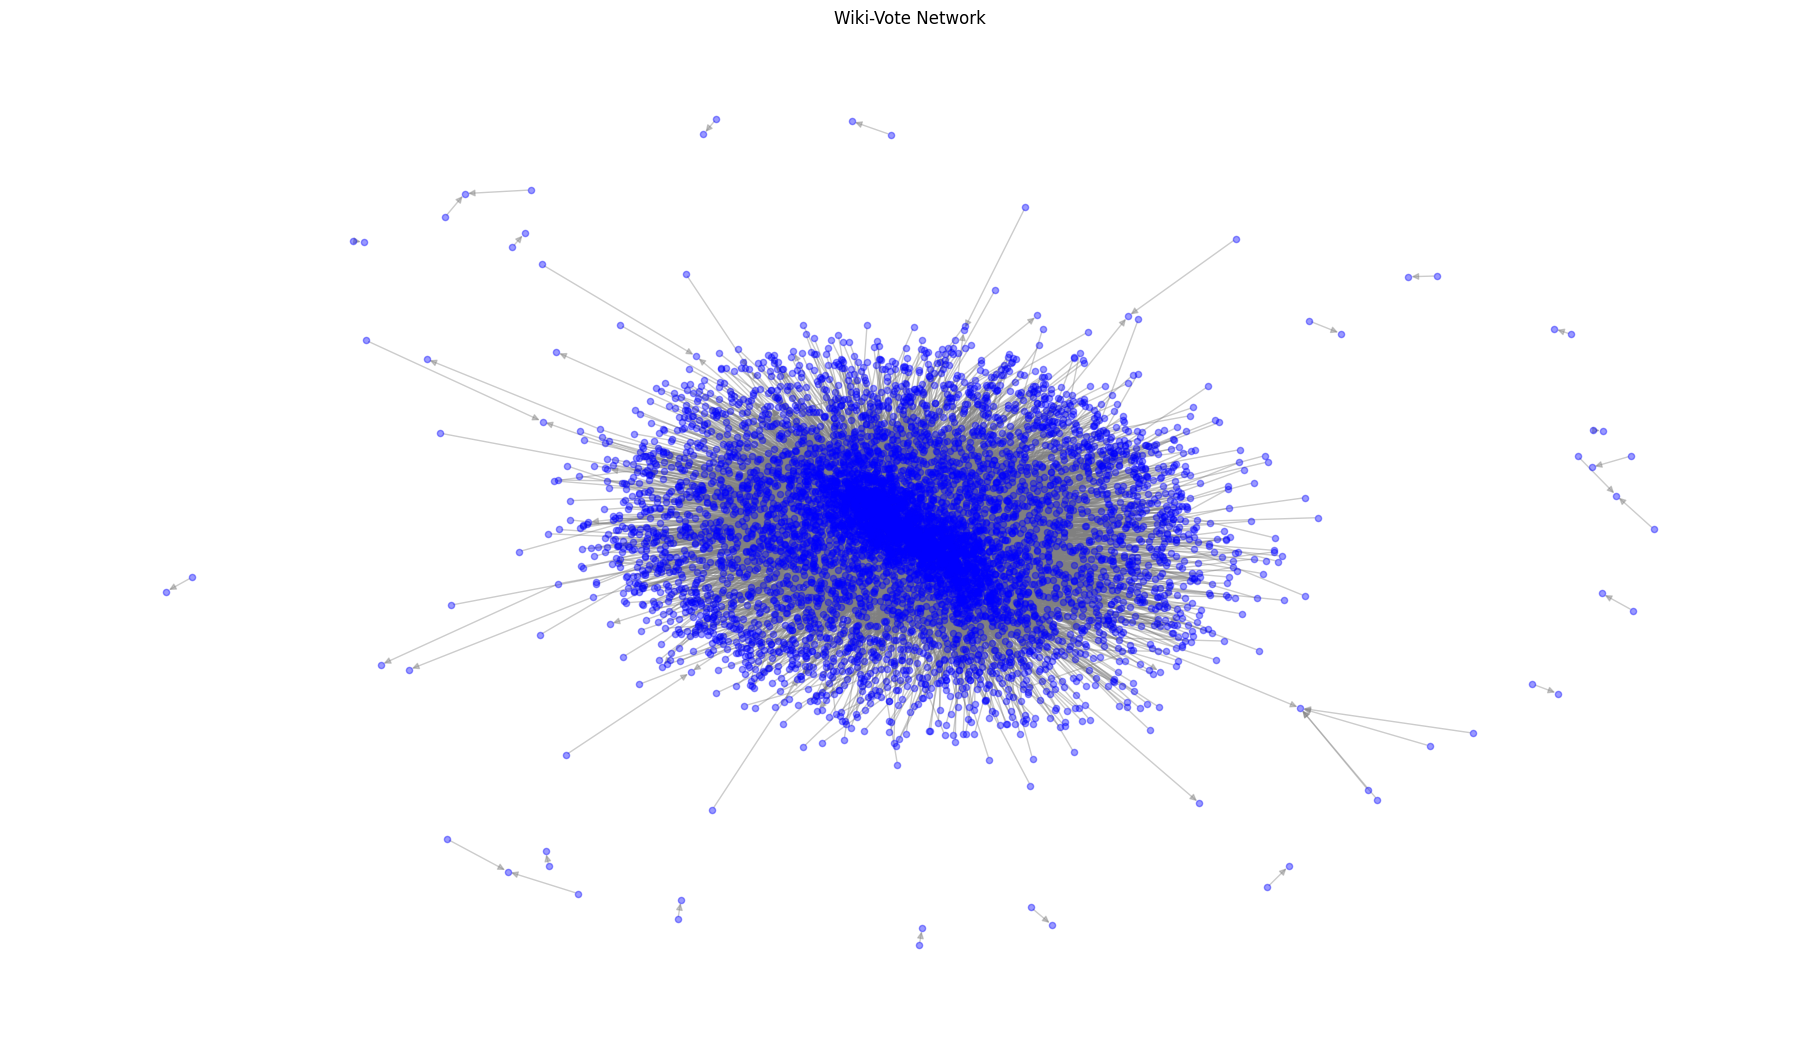

In [102]:
core_nodes = [node for node, degree in G_real.degree() if degree > 0]
G_core = G_real.subgraph(core_nodes)

plt.figure(figsize=(18,10))
nx.draw_spring(G_core, node_size=20, node_color="blue", alpha=0.4, edge_color="gray")
plt.title("Wiki-Vote Network")
plt.show()

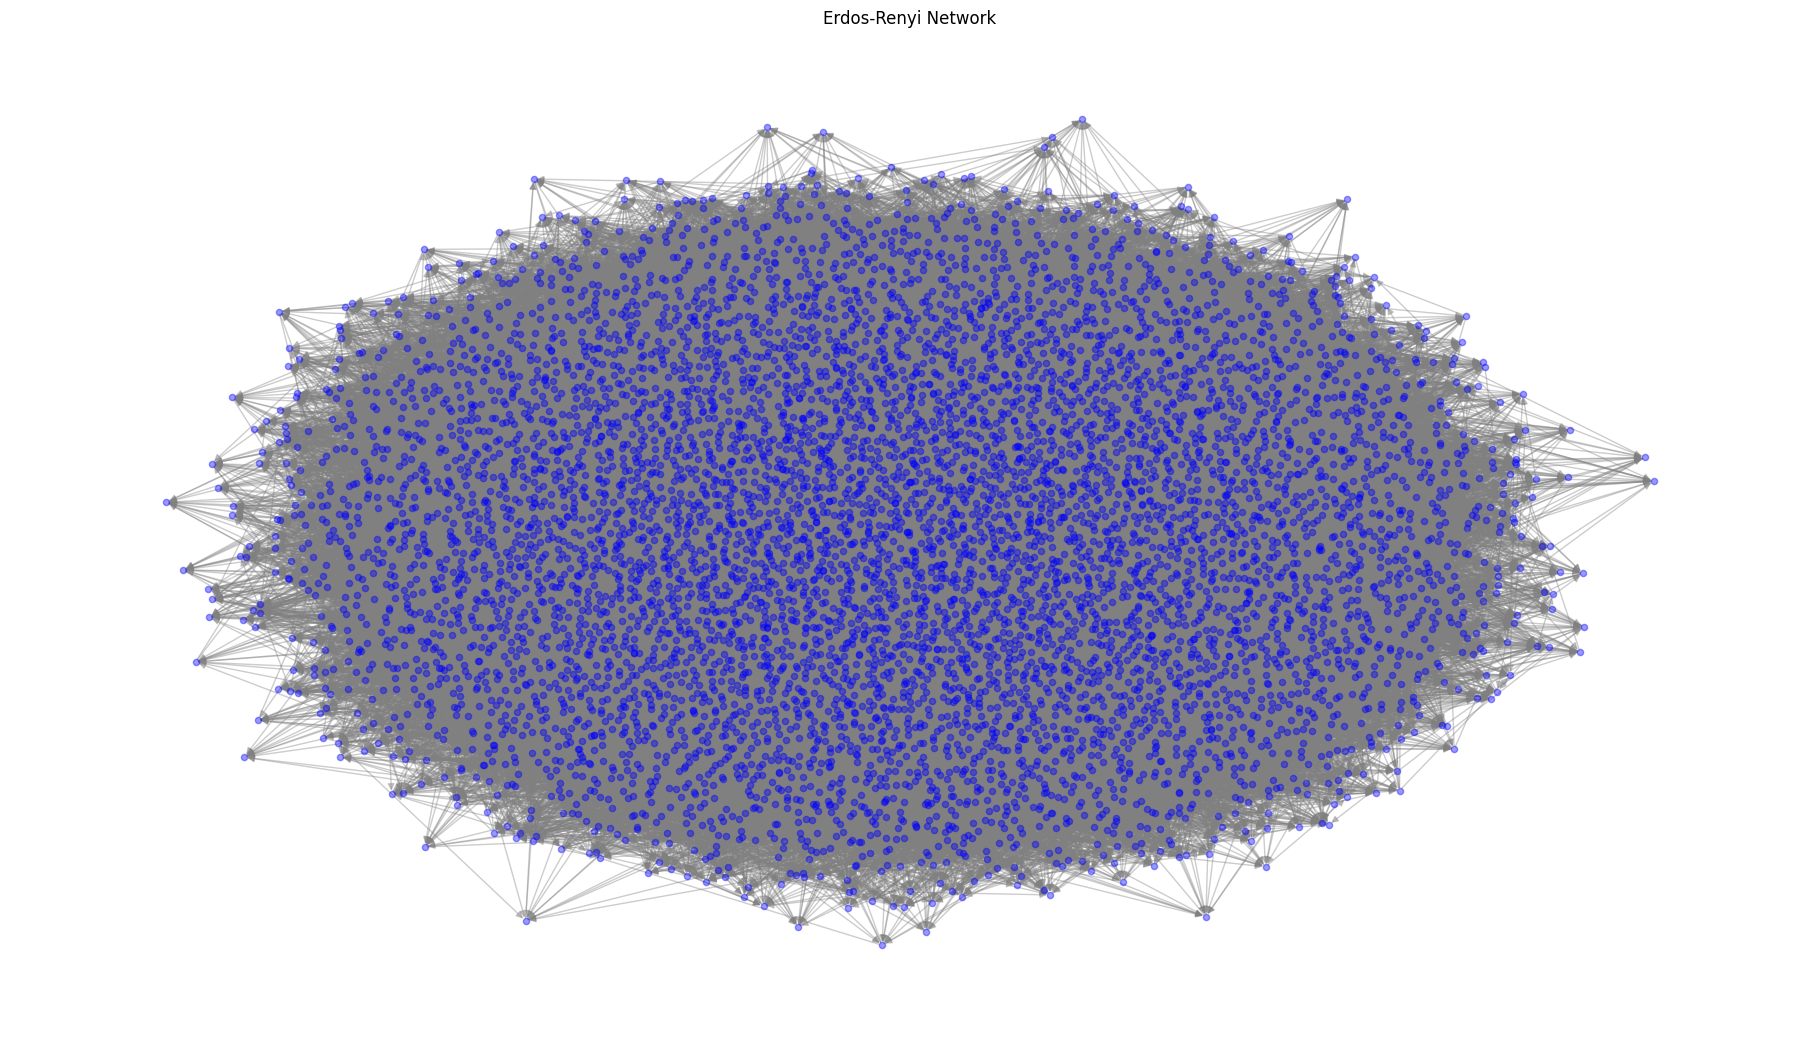

In [4]:
core_nodes = [node for node, degree in G_er.degree() if degree > 0]
G_core = G_er.subgraph(core_nodes)

plt.figure(figsize=(18,10))
nx.draw_spring(G_core, node_size=20, node_color="blue", alpha=0.4, edge_color="gray")
plt.title("Erdos-Renyi Network")
plt.show()

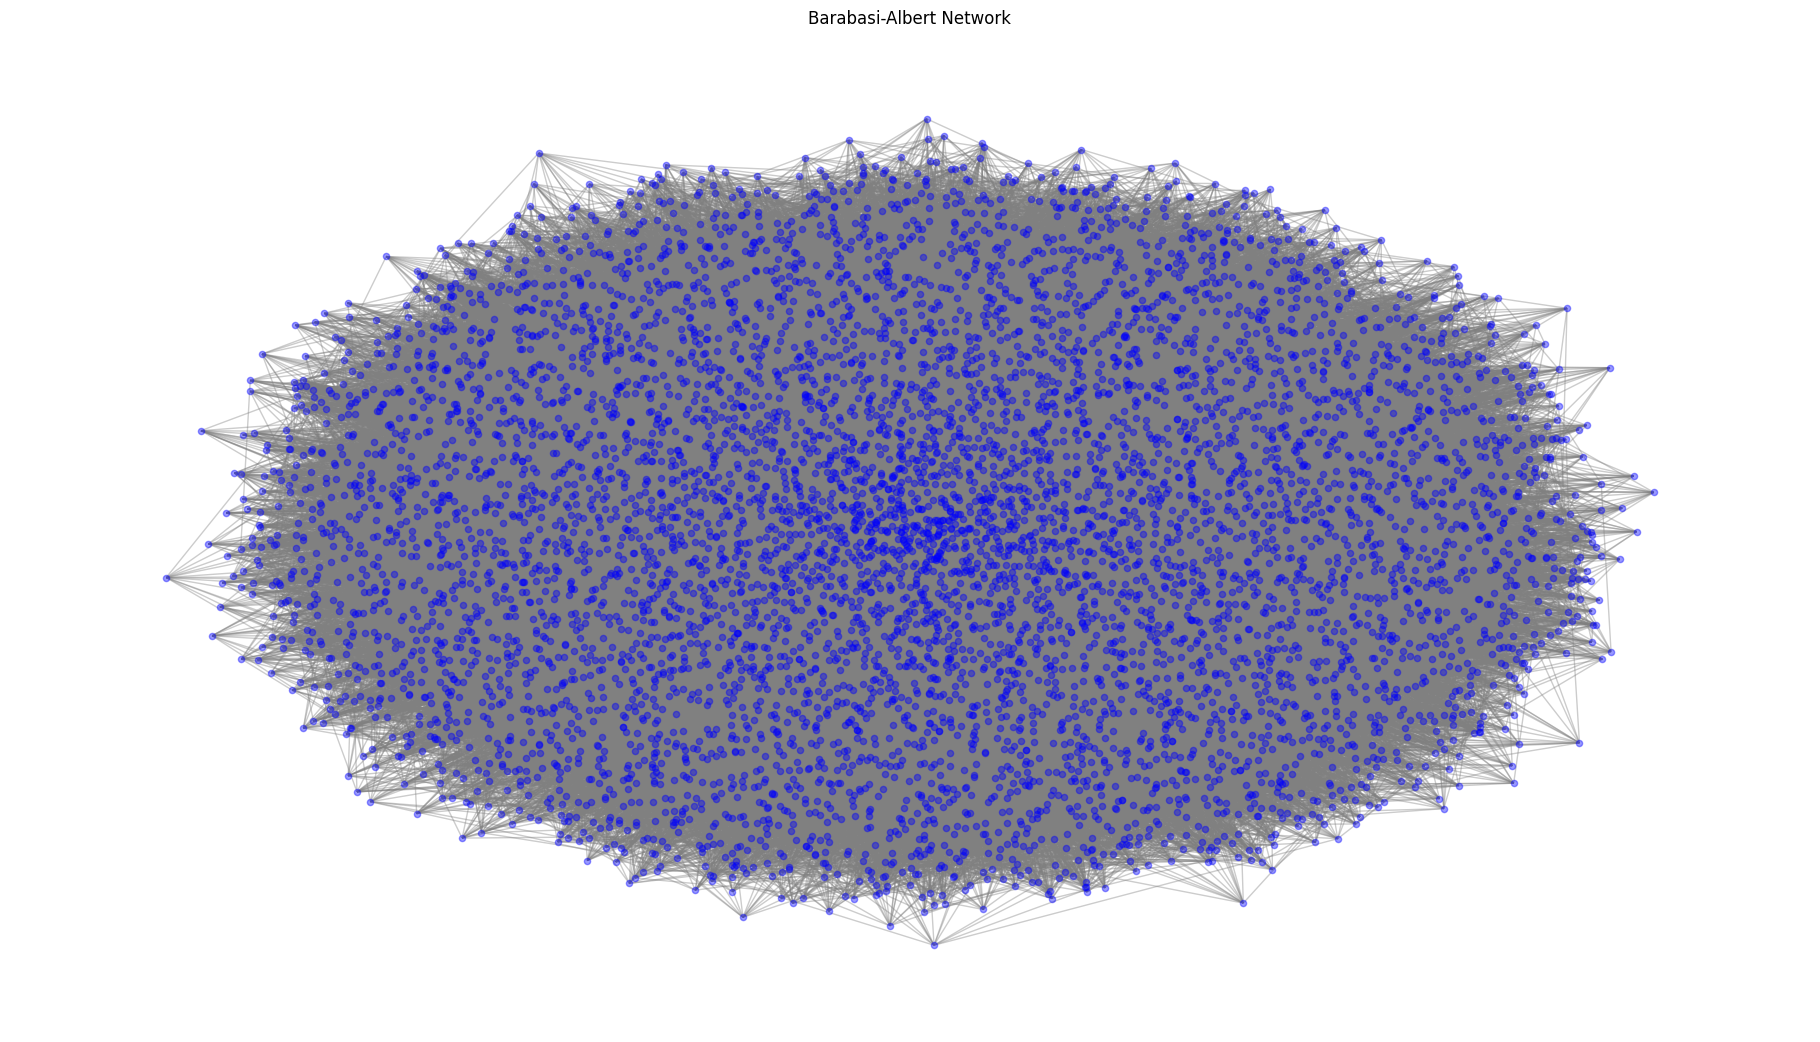

In [5]:
core_nodes = [node for node, degree in G_ba.degree() if degree > 0]
G_core = G_ba.subgraph(core_nodes)

plt.figure(figsize=(18,10))
nx.draw_spring(G_core, node_size=20, node_color="blue", alpha=0.4, edge_color="gray")
plt.title("Barabasi-Albert Network")
plt.show()

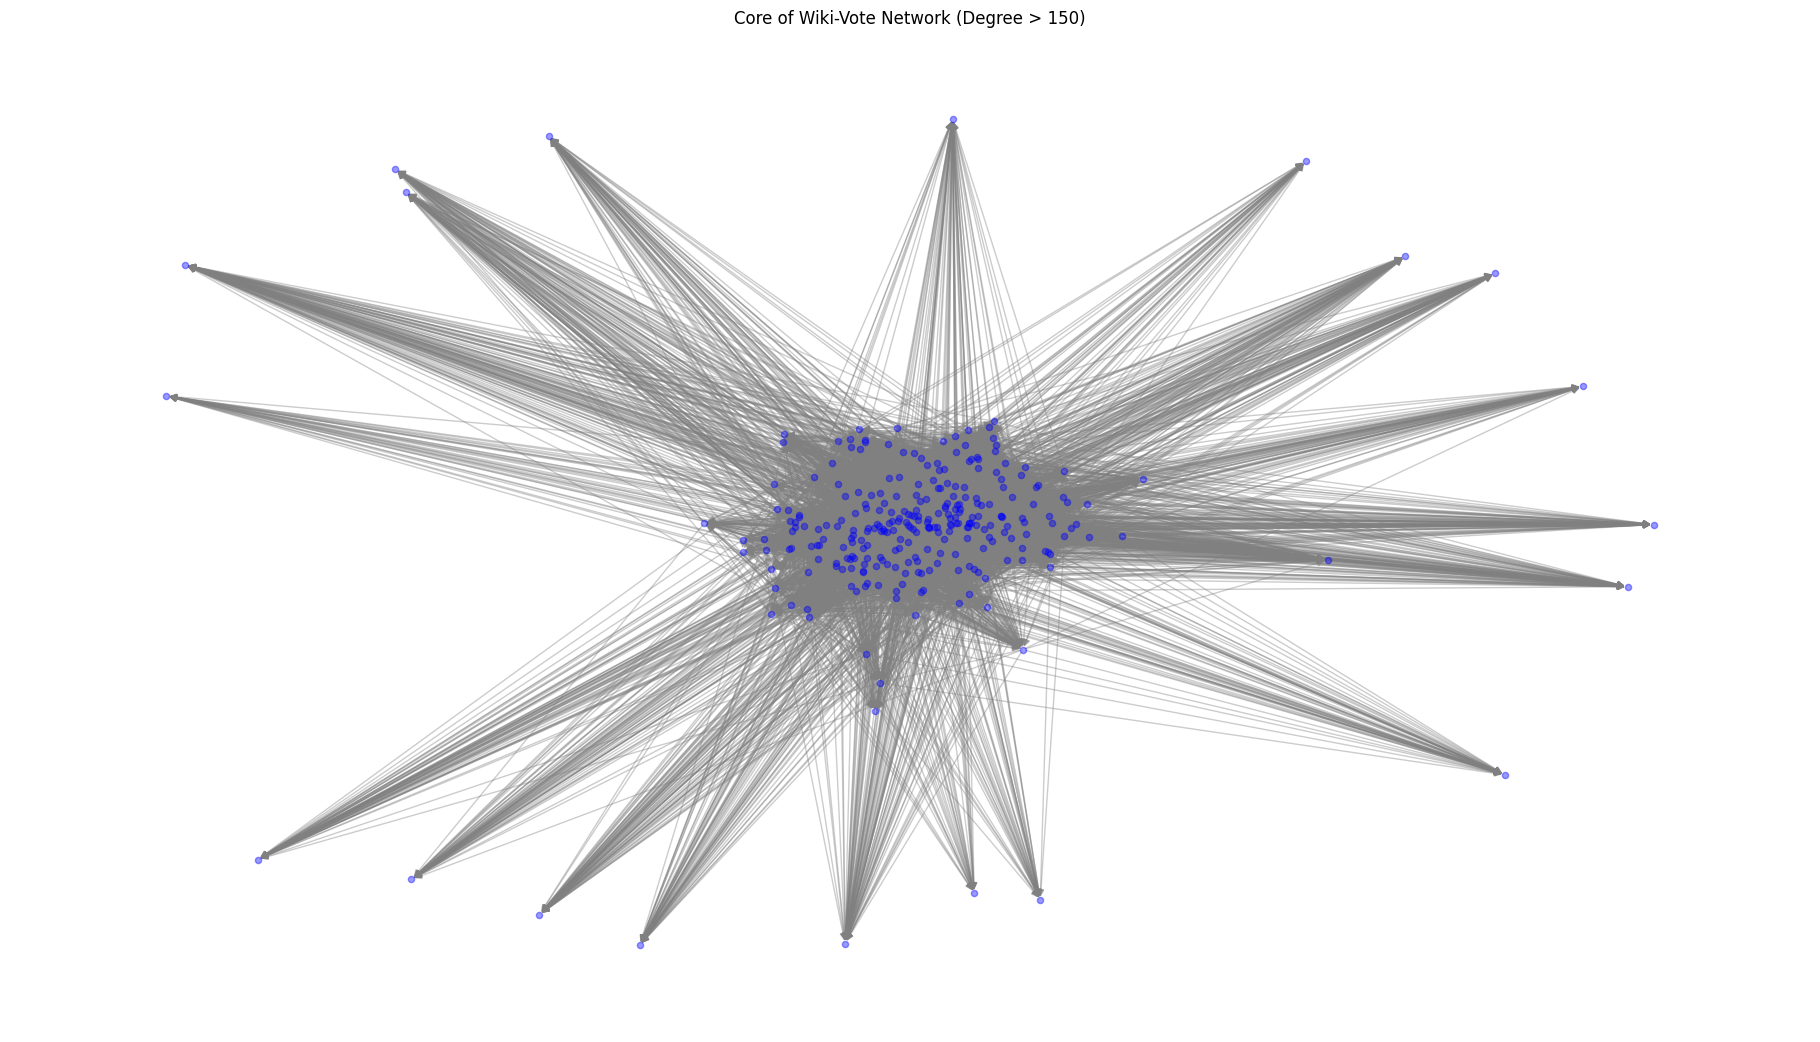

In [101]:
core_nodes = [node for node, degree in G_real.degree() if degree > 150]
G_core = G_real.subgraph(core_nodes)

plt.figure(figsize=(18,10))
nx.draw_spring(G_core, node_size=20, node_color="blue", alpha=0.4, edge_color="gray")
plt.title("Core of Wiki-Vote Network (Degree > 150)")
plt.show()

In [112]:
def plot_distributions(G, title):
    is_directed = G.is_directed()

    def show_hist(data, bins, plot_title, xlabel, ylabel, color=None, log_y=False, log_x=False):
        plt.figure(figsize=(8, 5))
        plt.hist(data, bins=bins, color=color, log=log_y)
        if log_x:
            plt.xscale("log")
        plt.title(f"{title}: {plot_title}")
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.tight_layout()
        plt.show()

    if is_directed:
        in_degrees = [d for _, d in G.in_degree()]
        show_hist(
            in_degrees,
            bins=50,
            plot_title="In-Degree Distribution",
            xlabel="In-Degree",
            ylabel="Count (log)",
            log_y=True,
            log_x=True,
        )

        out_degrees = [d for _, d in G.out_degree()]
        show_hist(
            out_degrees,
            bins=50,
            plot_title="Out-Degree Distribution",
            xlabel="Out-Degree",
            ylabel="Count (log)",
            log_y=True,
            log_x=True,
        )

        nodes = list(G.nodes())
        in_deg_vals = [G.in_degree(n) for n in nodes]
        out_deg_vals = [G.out_degree(n) for n in nodes]
        plt.figure(figsize=(8, 5))
        plt.scatter(in_deg_vals, out_deg_vals, alpha=0.3, s=5)
        plt.title(f"{title}: In-Degree vs Out-Degree")
        plt.xlabel("In-Degree")
        plt.ylabel("Out-Degree")
        plt.tight_layout()
        plt.show()

        clustering = list(nx.clustering(G).values())
        show_hist(
            clustering,
            bins=20,
            plot_title="Clustering Coefficient Distribution (Directed)",
            xlabel="Clustering Coefficient",
            ylabel="Count",
            color="green",
        )

        betweenness = list(nx.betweenness_centrality(G, k=100).values())
        show_hist(
            betweenness,
            bins=20,
            plot_title="Betweenness Centrality Distribution",
            xlabel="Betweenness Centrality",
            ylabel="Count (log)",
            color="red",
            log_y=True,
        )

        strong_comps = [len(c) for c in nx.strongly_connected_components(G)]
        show_hist(
            strong_comps,
            bins=20,
            plot_title="Strongly Connected Components Size Distribution",
            xlabel="Component Size",
            ylabel="Count (log)",
            color="purple",
            log_y=True,
        )

        weak_comps = [len(c) for c in nx.weakly_connected_components(G)]
        show_hist(
            weak_comps,
            bins=20,
            plot_title="Weakly Connected Components Size Distribution",
            xlabel="Component Size",
            ylabel="Count (log)",
            color="orange",
            log_y=True,
        )

    else:
        degrees = [d for _, d in G.degree()]
        show_hist(
            degrees,
            bins=50,
            plot_title="Degree Distribution",
            xlabel="Degree",
            ylabel="Count (log)",
            log_y=True,
            log_x=True,
        )

        clustering = list(nx.clustering(G).values())
        show_hist(
            clustering,
            bins=20,
            plot_title="Clustering Coefficient Distribution (Undirected)",
            xlabel="Clustering Coefficient",
            ylabel="Count",
            color="green",
        )

        betweenness = list(nx.betweenness_centrality(G, k=100).values())
        show_hist(
            betweenness,
            bins=20,
            plot_title="Betweenness Centrality Distribution",
            xlabel="Betweenness Centrality",
            ylabel="Count (log)",
            color="red",
            log_y=True,
        )

        comps = [len(c) for c in nx.connected_components(G)]
        show_hist(
            comps,
            bins=20,
            plot_title="Connected Components Size Distribution",
            xlabel="Component Size",
            ylabel="Count (log)",
            color="purple",
            log_y=True,
        )

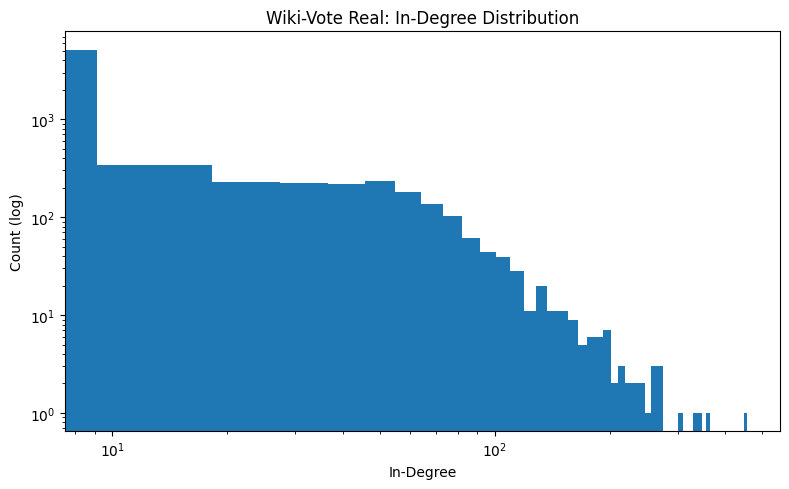

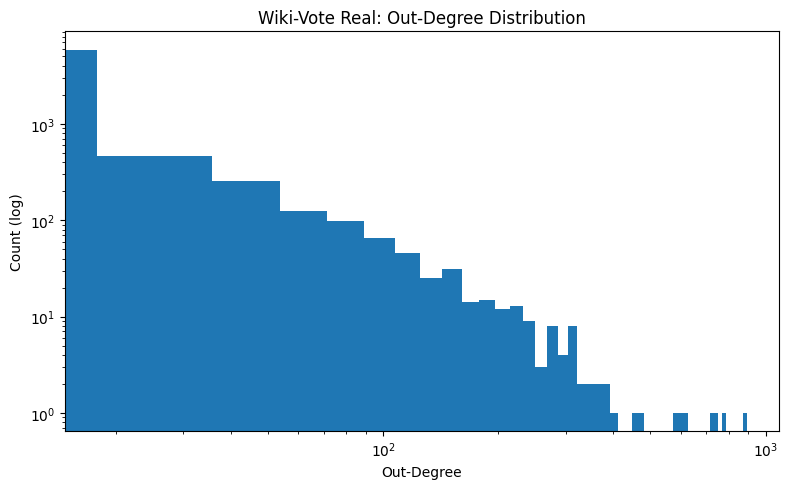

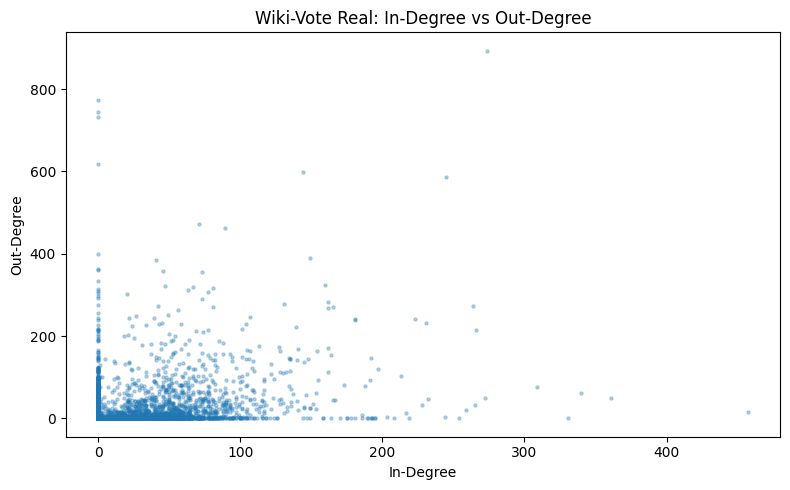

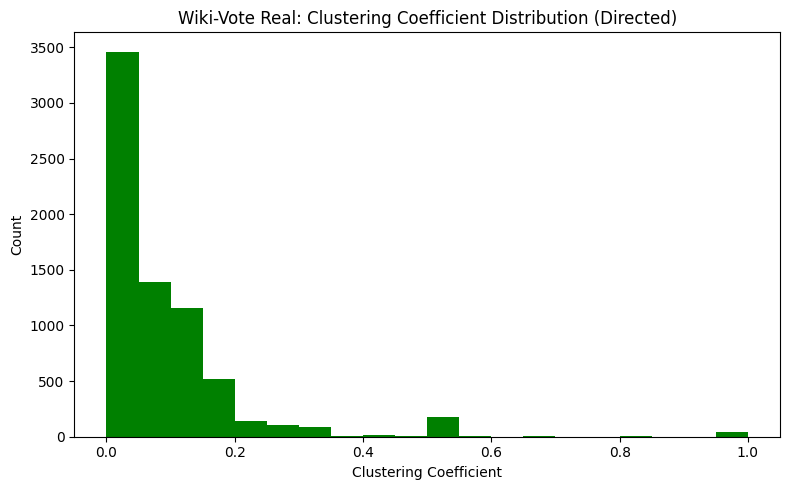

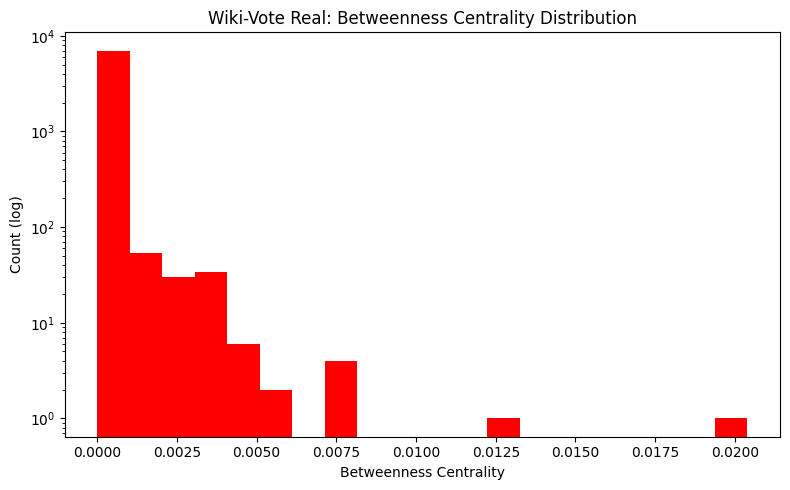

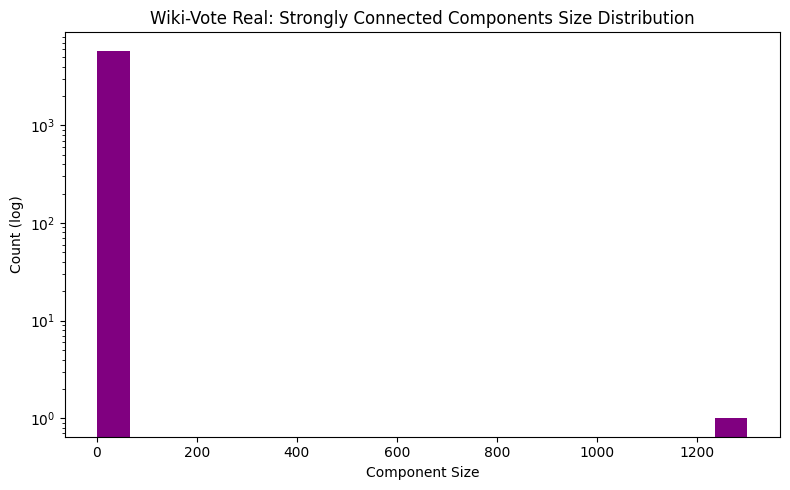

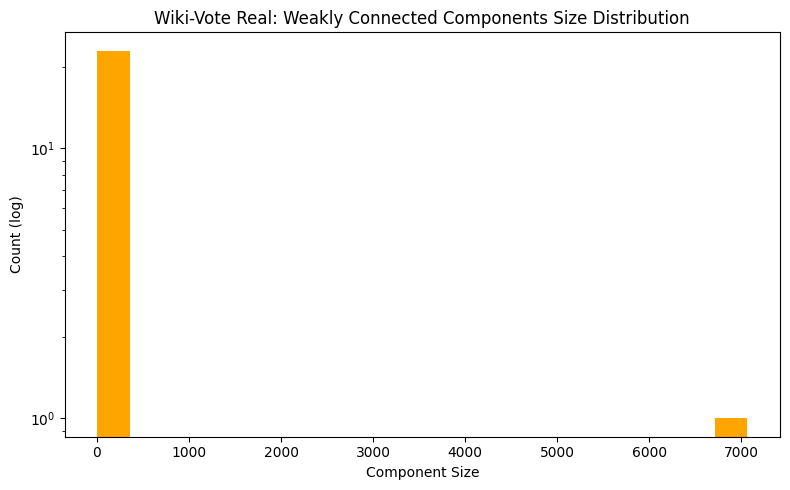

In [113]:
plot_distributions(G_real, "Wiki-Vote Real")

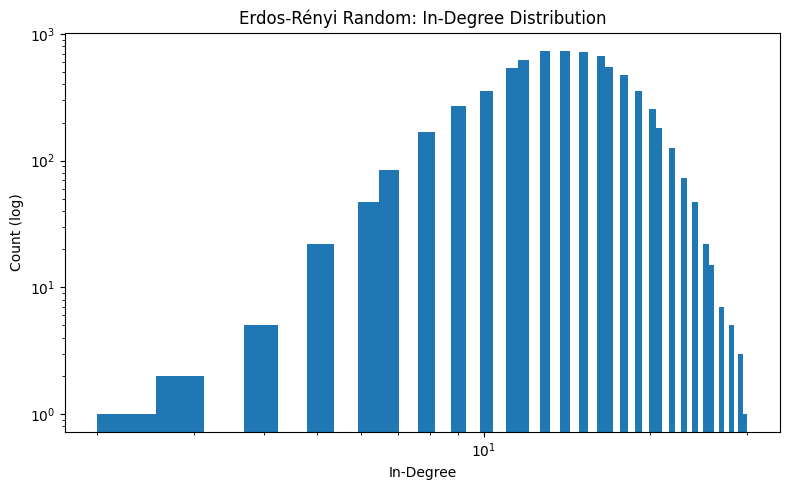

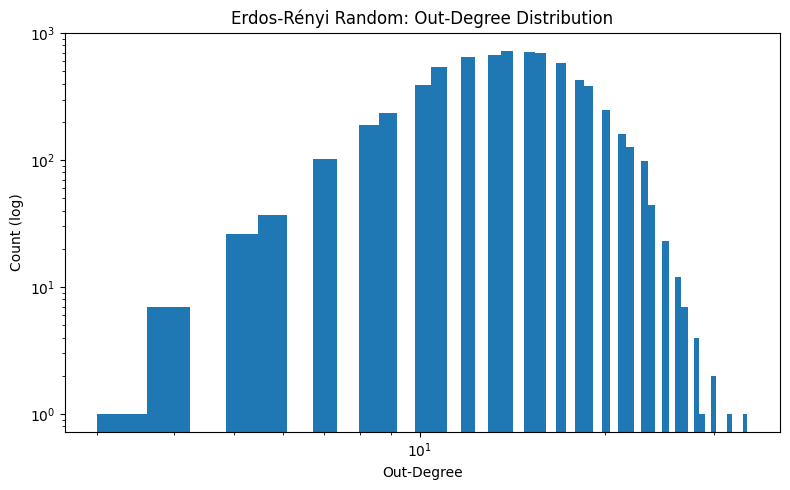

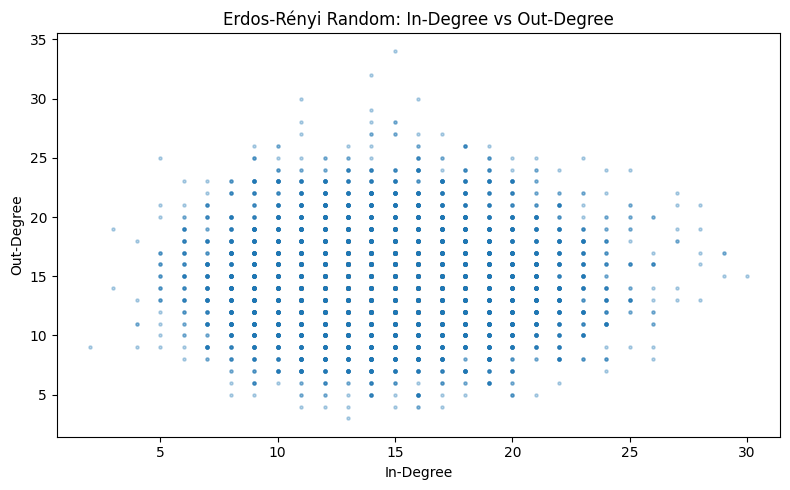

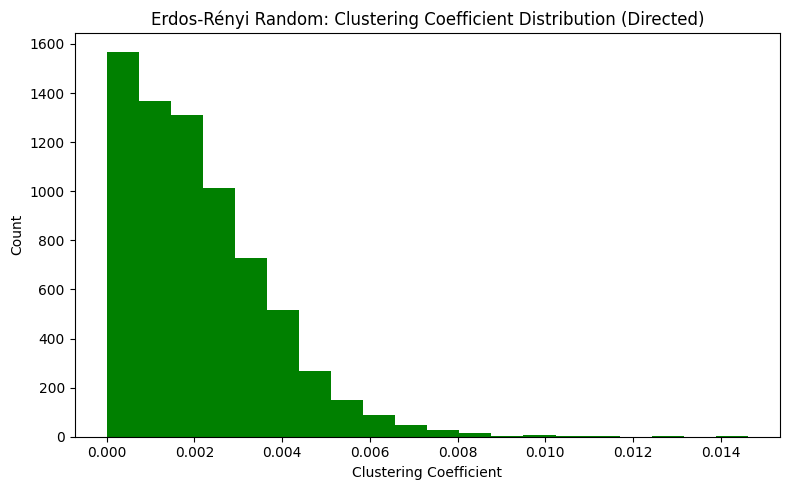

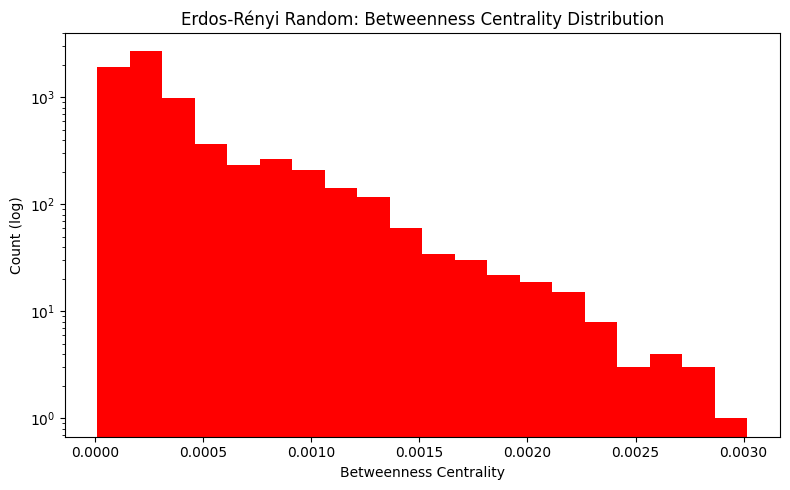

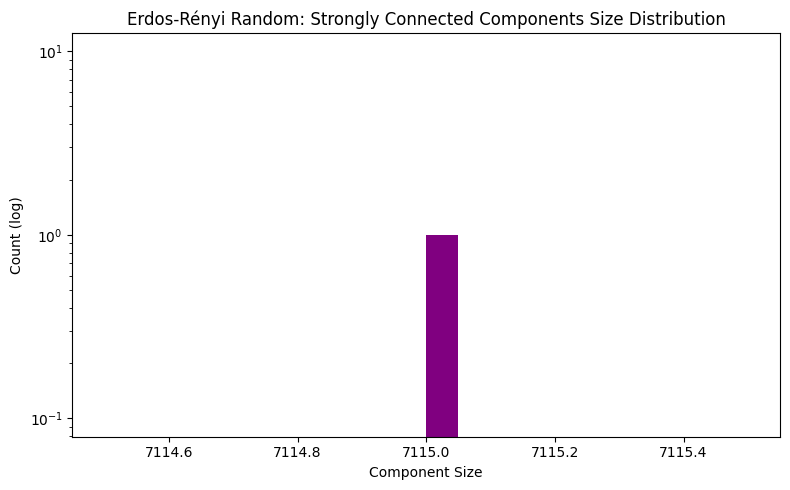

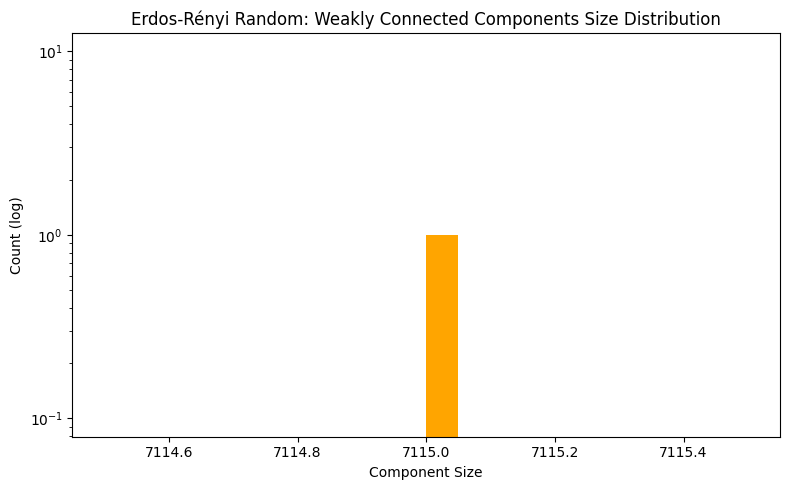

In [114]:
plot_distributions(G_er, "Erdos-Rényi Random")

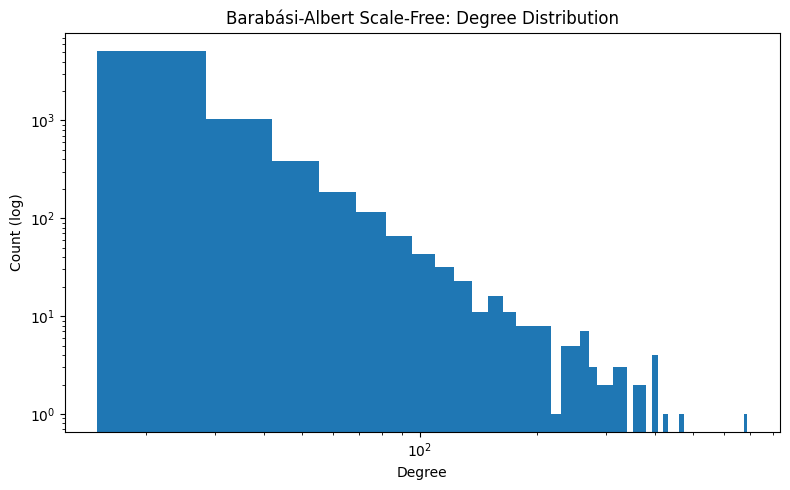

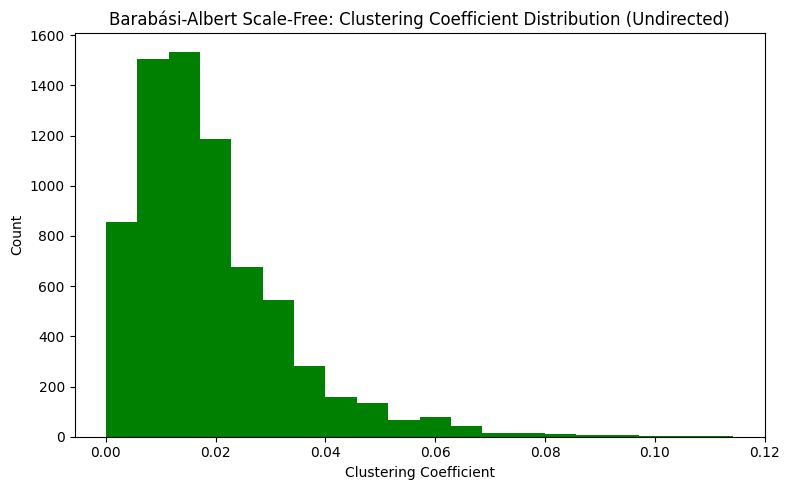

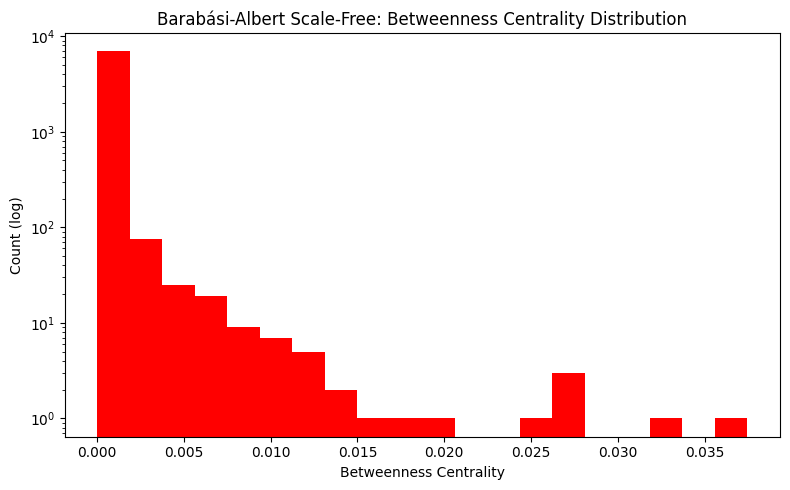

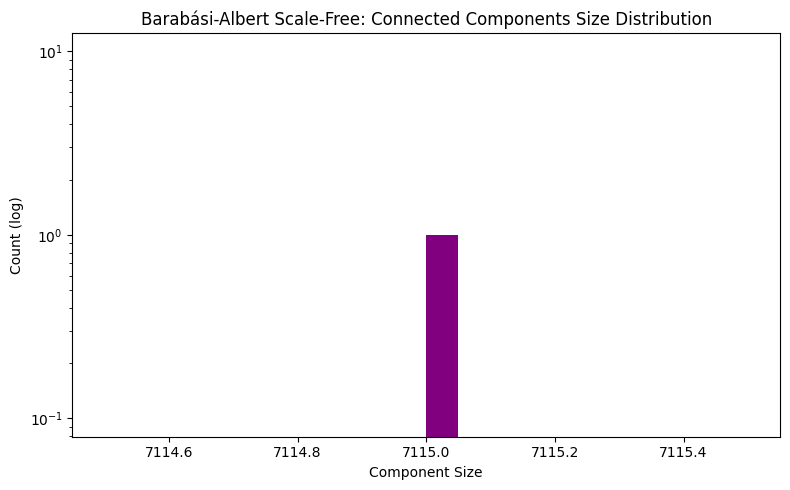

In [115]:
plot_distributions(G_ba, "Barabási-Albert Scale-Free")